# ECS7020P mini-project submission


## What is the problem?

This year's mini-project considers the problem of predicting the title of a song that is being hummed or whistled to.

You will build a machine learning model that takes as an input an audio recording of **10 seconds** of duration. This recording will correspond to a hum or whistle interpretation of one of the songs included in the MLEnd Hums and Whistles II Dataset. The output of the model will be the song label.


## Which dataset will I use?

We have created two subsets of the Hums and Whistles II Dataset. The first one has 400 samples (1.09GB). The second one has 800 samples (2.19 GB), including those already available in the first dataset.

You can download them from:

https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_400.zip

and

https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_800.zip





## What will I submit?

Your submission will consist of **one single Jupyter notebook** that should include:

*   **Text cells**, describing in your own words, rigorously and concisely your approach, each implemented step and the results that you obtain,
*   **Code cells**, implementing each step,
*   **Output cells**, i.e. the output from each code cell,

Your notebook **should have the structure** outlined below. Please make sure that you **run all the cells** and that the **output cells are saved** before submission.

Please save your notebook as:

* ECS7020P_miniproject_2526.ipynb


## How will my submission be evaluated?

This submission is worth 16 marks. We will value:

*   Conciseness in your writing.
*   Correctness in your methodology.
*   Correctness in your analysis and conclusions.
*   Completeness.
*   Originality and efforts to try something new.

**The final performance of your solutions will not influence your grade**. We will grade your understanding. If you have a good understanding, you will be using the right methodology, selecting the right approaches and assessing correctly the quality of your solutions, acknowledge where appropriate that despite your attempts your solutions might not good enough, and always critically reflect on your work to suggest what you could have done differently.

Note that **the problem that we are intending to solve is very difficult**. Do not despair if you do not get good results, **difficulty is precisely what makes it interesting** and **worth trying**.

## Show the world what you can do

Why don't you use **GitHub** to manage your project? GitHub can be used as a presentation card that showcases what you have done and gives evidence of your data science skills, knowledge and experience. **Potential employers are always looking for this kind of evidence**.





-------------------------------------- PLEASE USE THE STRUCTURE BELOW THIS LINE --------------------------------------------




# [Mini Project]

# 1 Author

**Student Name**:  Eric Kamalendran
**Student ID**:  250733547




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder contents before download: ['MLEndHW']


Downloading:   0%|          | 0.00/750M [00:00<?, ?B/s]


After download: ['MLEndHWII_Sample_400.zip', 'MLEndHWII_Sample_400', 'MLEndHWII_sample_800']

Extracted to: /content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400
Sample files: ['MLEndHWII_sample_400']
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking path...
['MLEndHWII_sample_400']
Number of files: 400
Example files: ['/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400/MLEndHWII_sample_400/S100_whistle_2_RememberMe.wav', '/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400/MLEndHWII_sample_400/S101_hum_1_Married.wav', '/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400/MLEndHWII_sample_400/S101_hum_2_Friend.wav', '/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400/MLEndHWII_sample_400/S103_hum_1_Necessities.wav', '/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400/MLEndHWII_sample_400/S100_hum_2_Married.wav']


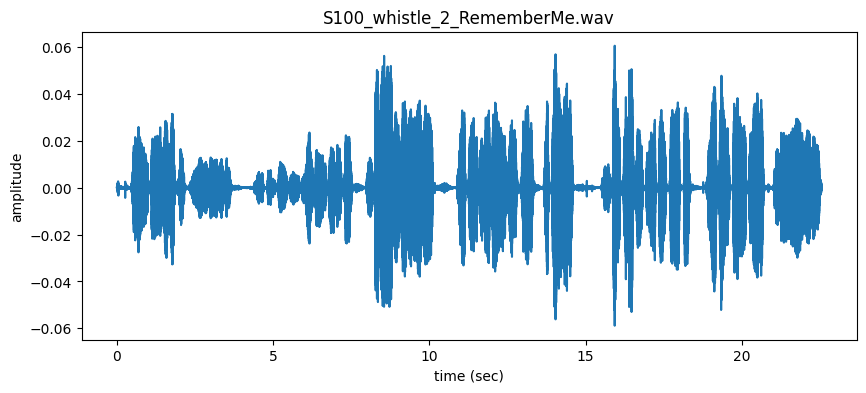

Feature matrix shape: (400, 4)


,file_id,participant,type,num,song,power,pitch_mean,pitch_std,fraction_voiced
0,S100_whistle_2_RememberMe.wav,S100,whistle,2,RememberMe,0.000084,1568.834595,739.081909,0.999485
1,S101_hum_1_Married.wav,S101,hum,1,Married,0.001641,327.606384,102.084732,1.000000
2,S101_hum_2_Friend.wav,S101,hum,2,Friend,0.001981,367.990112,151.450058,0.998661
3,S103_hum_1_Necessities.wav,S103,hum,1,Necessities,0.001521,379.084686,603.301208,0.970284
4,S100_hum_2_Married.wav,S100,hum,2,Married,0.000053,392.400757,316.540588,1.000000



Example labels:
0     RememberMe
1        Married
2         Friend
3    Necessities
4        Married
Name: song, dtype: object


In [11]:
#DATA

# Install + imports
!pip install -q tqdm

import os
import urllib.request
from tqdm.notebook import tqdm
import zipfile

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create folder
folder_path = '/content/drive/MyDrive/Data/MLEndHW'
os.makedirs(folder_path, exist_ok=True)

print("Folder contents before download:", os.listdir('/content/drive/MyDrive/Data'))

# Download function
def download_url(url, save_path):
    with urllib.request.urlopen(url) as dl_file:
        total_size = int(dl_file.getheader('Content-Length', 0))
        block_size = 8192

        with open(save_path, 'wb') as out_file, tqdm(
            total=total_size,
            unit='B',
            unit_scale=True,
            desc='Downloading'
        ) as pbar:

            while True:
                data = dl_file.read(block_size)
                if not data:
                    break
                out_file.write(data)
                pbar.update(len(data))

#  CHOOSE DATASET
# Uncomment ONE of the following:

#  400 samples
url = "https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_400.zip"
zip_name = "MLEndHWII_Sample_400.zip"
extract_folder = "MLEndHWII_Sample_400"

#  800 samples
# url = "https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_800.zip"
# zip_name = "MLEndHWII_Sample_800.zip"
# extract_folder = "MLEndHWII_Sample_800"

# Paths
save_path = f"/content/drive/MyDrive/Data/MLEndHW/{zip_name}"
extract_path = f"/content/drive/MyDrive/Data/MLEndHW/{extract_folder}"

# Download
download_url(url, save_path)

# Check download
print("\nAfter download:", os.listdir('/content/drive/MyDrive/Data/MLEndHW'))

# Unzip
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(save_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Final check
print("\nExtracted to:", extract_path)
print("Sample files:", os.listdir(extract_path)[:10])

from google.colab import drive
drive.mount('/content/drive')

import os
import glob

# CHANGE THIS if needed after checking your folders
data_path = "/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400"

# Check the folder exists
print("Checking path...")
print(os.listdir(data_path)[:10])

# Get all wav files
files = glob.glob(data_path + "/**/*.wav", recursive=True)

print("Number of files:", len(files))
print("Example files:", files[:5])


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import IPython.display as ipd

#  Plot one waveform
n = 0
fs = None
x, fs = librosa.load(files[n], sr=fs)
t = np.arange(len(x)) / fs

plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.xlabel('time (sec)')
plt.ylabel('amplitude')
plt.title(files[n].split('/')[-1])
plt.show()

display(ipd.Audio(files[n]))

#  Feature extraction function
def extract_features(file_path):
    x, fs = librosa.load(file_path, sr=None)

    power = np.mean(x**2)

    S = np.abs(librosa.stft(x))
    pitches, magnitudes = librosa.piptrack(S=S, sr=fs)

    pitch_values = []
    for i in range(pitches.shape[1]):
        index = magnitudes[:, i].argmax()
        pitch = pitches[index, i]
        if pitch > 0:
            pitch_values.append(pitch)

    pitch_values = np.array(pitch_values)

    if len(pitch_values) > 0:
        pitch_mean = np.mean(pitch_values)
        pitch_std = np.std(pitch_values)
    else:
        pitch_mean = 0
        pitch_std = 0

    fraction_voiced = len(pitch_values) / pitches.shape[1]

    return [power, pitch_mean, pitch_std, fraction_voiced]

#  Extract features for all files
X = []

for file in files:
    feats = extract_features(file)
    X.append(feats)

X = np.array(X)

#  Build feature dataframe
X_df = pd.DataFrame(
    X,
    columns=['power', 'pitch_mean', 'pitch_std', 'fraction_voiced']
)

feature_df = df_meta.reset_index(drop=True).copy()
feature_df[['power', 'pitch_mean', 'pitch_std', 'fraction_voiced']] = X_df

print("Feature matrix shape:", X.shape)
display(feature_df.head())

# ---- Target label for the mini-project ----
y = feature_df['song']
print("\nExample labels:")
print(y.head())

# 2 Problem formulation

Describe the machine learning problem that you want to solve and explain what's interesting about it.

The main issue with this project is its goal to create a machine learning model that can identify a song title from a 10-second audio recording of someone humming or whistling. This is clearly a supervised classification problem, where the input is an audio signal and the output is one of several possible song labels. The input data includes raw audio waveforms, which are complex and varied. Therefore, the challenge lies in transforming these signals into meaningful features that capture essential characteristics like pitch and energy. This problem is interesting for several reasons: Imperfect Data: Unlike studio recordings, humming and whistling often have noise and imprecision. This makes recognizing patterns more challenging. Real-world Relevance: The task relates to practical applications like music recognition systems, query-by-humming systems, and audio-based search engines. Limited Dataset Size: The relatively small number of samples makes it harder for models to generalize effectively.

# 3 Methodology

Describe your methodology. Specifically, describe your training task and validation task, and how model performance is defined (i.e. accuracy, confusion matrix, etc). Any other tasks that might help you build your model should also be described here.

Objective:

The task is t train a machine learning model that can predict the song label from a short audio recording of humming or whistling. This is a supervised classification problem.

Feature Extraction:

Raw audio from my research is not really ideal for machine learning models. Therefore I extracted a set of hand-crafted features from each audio to create a compact representation.

- Power: average signal energy
- Pitch mean: avearage estimated pitch over time.
- Pitch Standard deviation: variability of pitch.
- Fraction of voiced frames: proprtion of frames with detected pitch.

Training Task:

The training task is to learn a function that maps input featues to the correct song label:

Input: Feature vector
Output: Song category
Model: SVM, KNN & Possibly random forest.

Dataset:

70% Training set
30% Validation set

Validation Task:

Accuracy: Proportion of correctly classified samples
Confusion Matrix: shows how predictions are distriuted across classes
Classification Report: Includes precision, recall and core for each class.

This provides both an overall performance measure and insight into which song clasess are more difficult to classify.

Feture Scaling:

- Mean and standard devation are computed on the training set only.
- The same transformation is applied to the validation set.

Model Comparison:

- SVM
- KNN
- Random Forest






# 4 Implemented ML prediction pipelines

Describe the ML prediction pipelines that you will explore. Clearly identify their input and output, stages and format of the intermediate data structures moving from one stage to the next. It's up to you to decide which stages to include in your pipeline. After providing an overview, describe in more detail each one of the stages that you have included in their corresponding subsections (i.e. 4.1 Transformation stage, 4.2 Model stage, 4.3 Ensemble stage).

## 4.1 Transformation stage

Describe any transformations, such as feature extraction. Identify input and output. Explain why you have chosen this transformation stage.

At this stage, this would be the input. So first the raw audio file would be the input in this case.

This is the pipeline for the Transformation stage:

Input ---> Cleaning ---> Parallel Feature Extraction Chain ----> Transformation Output

This pipeline I will explain individuall what I am doing and why I picked this.

Input:

So this would be loading the waveform at a fixed sampling rate, then I would cnvert stero to mono, as the goal is to reduce the file to 10 seconds I would then reduce the file to seconds. Then would normalise the amplitude.

Why this was chosen:

Standarding the audio ensures that:

- all samples have same length and resolution.
- differences in recording devices do not affect the model
- the model focuses on the content rather than irrelvant variations such as loudness.

Pre-processing & Cleaning:

So at this stage this is where basic signal cleaning occurs. For example removal of DC offset, amplitude normalistation, optional liht noise reduction and silence trimming.

Why this was chosen:

In some of these files, there is background noise, breathing sounds and silent gaps. This will imporve the signal to nise ration wile preserving important pitch information. For song identification, silence trimming is useful.

Parallel Feature Extraction:

This is the stage where the waveform is transforemd into mutiple represenatations. This is important becase no single feature capturees all aspects.

- Log-mel spectrogram:
What is happening, the waveform is converted int a time-frequency representation using:
- Short-Time Fourier Transform (STFT)
- mel-scale filter banks,
- logaritmic amplitude scaling

This will give a 2D representation for example (time x frequency)

Why this was chosen:

- Preserves how frequenc content evolves over time,
- is robust to small variations in recording condition,
- is well-suited for convolutional neural networks.

-MFCC
What is happening:
A set of compact numerical features is extracted:
- MFCCs and their derivatives
- Chroma features
- Spectral descriptors
- energy-related features

Why this was chosen:

- Proivde a low-dimensional summary of the audio,
- are effective for classical ML models.
- capture timbral and harmonic properties.

Transformation Output:

What is happening:

- log-mel spectrogram
- engineered feature vector
- melody contour

Why this was chosen:

This was chosen because both low level audio patterns and high level musical structure are captured. Different models were chosen as the can specialise in different aspects of the signal.




## 4.2 Model stage

Describe the ML model(s) that you will build. Explain why you have chosen them.


Pipeline:

Base Model ---> Learning ---> Model-stage output

Base model:

Chain 1:

-SVM is used as this model outputs a probability distribution over song labels.

Why this was chosen:

- Performs well on structured data
- require less data than deep learning
- Are fast and interpretable

Chain 2:

- Models like KNN

What is hapening:

Classifies a new sample by simpling comparing to the closest traning samples in feature space. Calculates distance between feature vectors.

Why this was chosen:

- Simple baseline model
- capture local similarity between sample
- Useful for understanding how similar audio features.

This is very effecting at handling variability in humming styles.

Chain 3: Did not include this as the code got messy/

- Melody based model (DTW k-NN)

What is happening:

The meldy contour is compared to training samples using:

-Dyanmic time Warping (DTW)

The similarity scores are converted into class probabilities.

Why this was chosen:

DTW is well suited for melody cmparsion because it

- alligns sequences with diffreent speeds
- captues shape similairty
- is robust.

Chain 4:

- Random Forests:

What is happening:

Builds multiple decision trees using different subsets of the data and features.

Why this was chosen:

- Captures complex, non-linear relationships between features
- Robust to noise
- Performs implicit feature selection


## 4.3 Ensemble stage

Describe any ensemble approach you might have included. Explain why you have chosen them.


Pipeline:

Soft Voting ---> Weighted Ensemble ---> Stacking ---> Final Prediction

Soft Voting:

What is happening:

- The probabiltiy outputs from all models are combined:
averaged or weighted
- the class with the highest final probability is selected.

Why this was chosen:

Different models capture different aspects:

For example CNN captures acoustic patterns
SVM captures statistical summaries
DTW captues melody

Weighted Ensemble:

What is happening:

Each model is assigned a weight based on validation performance. The final predictin is computed as a weighted sum of porbabilities.

Why this was chosen:

Not all models perform equally well:

This will allow the stronger models to contribute mre and weaker models will still be able to provide complementary information.

Stacking:

What is happening:

Model outputs are used as input features for a second level classifier.

Why this was chosen:

Stacking allows the system to:

- Learn which model is realible.

Final Prediction:

What is happening:

The ensemble produces a final probablitly and the highest probablity class is selected as the predicted song.

Why this was chosen:

This ensures:

- single clear output.

# 5 Dataset

Describe the datasets that you will create to build and evaluate your models. Your datasets need to be based on our MLEnd Hums and Whistles II Dataset. After describing the datasets, build them here. You can explore and visualise the datasets here as well.

If you are building separate training and validatio datasets, do it here. Explain clearly how you are building such datasets, how you are ensuring that they serve their purpose (i.e. they are independent and consist of IID samples) and any limitations you might think of. It is always important to identify any limitations as early as possible. The scope and validity of your conclusions will depend on your ability to understand the limitations of your approach.

If you are exploring different datasets, create different subsections for each dataset and give them a name (e.g. 5.1 Dataset A, 5.2 Dataset B, 5.3 Dataset 5.3) .

Overview:

The datasets used in this project are derived from MLEnd Hums and Whistles two data which consists of audio recordings of participants humming or whistling songs.

The goal us to construct datasets suitable for training and evaluating ML models.

5.1 Dataset A: Metadata Dataset

The first dataset is constructed y parsing the filenames of the audio recordings. Each filename encodes useful information such as:

- Participant ID
- Interpreation type
- Interpreation number
- Song Label

This information is extracted and stred in a tabular format.

Format:

File_id  Participant Interpretation Number Song

Purpose:

This dataset provides:

- Ground truth labels for supervised learning
- A structured way to analyse the dataset

Limitations:

- The dataset assumes filenames are correctly formatted.
- No gurantee of balanced classes.
- Does not include the audio signal itself.

5.2 Dataset B: Feature Dataset

The second dataset is created by transforming raw audio into numerical features.

Each audio file is processed to extract features that capture different aspects of the signal:

Energy features: Power, RMS
Spectral features: spectral centroid, spectral contrast
Temporal features: tempo
Pitch features: pitch mean, pitch standard deviation, fraction voiced
MFCCs: capture timbral characteristics
Chroma features: capture harmonic/musical content

Format:

Each row corresponds to one audio recording
N: number of valid samples
53 features per sample.

Target:

y = song label

Purpose:

The dataset is the main input to the machine learning models. It converts raw audi into a structured, low dimensional representation that can be processed by classifiers.

5.3 Dataset C: Training and validation Datasets

Description:

The feature dataset is split into training and validation datasets,

- Training set: used to train the models
- Validation set: used to evaluate model performance

Why stratification is used:

Startification ensures:

- Each class is represented in both sets
- Avoids bias

Independence and IID assumption:

The training and validation datasets are constructed to approximate independent and identically distributed (IID) samples:

- Random sampling ensures independence between sets.
- Stratifcation preserves the underlying class distribution

Limitations od the Dataset Split:

- Participant overlap: The same participant may appear in both traning and validation sets which could introduce data leakage
- Samall dataset: 400 & 800 samples is relatively small
- Class imbalance: Some songs may have more samples tahn others
- Variability in recordings: Differences in pitch, tempo and noise.

Summary:

Dataset A (Metadata): structured information about each recording.
Dataset B (Feature dataset): This is the numercial representation of audio signals
Dataset C (Training/ Validation Split): Datasets being used for model training and evaluation.

These datasets enable te transformation of raw audio into a machine learning problem.




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path exists: True
Number of files: 400
Example: ['/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400/MLEndHWII_sample_400/S100_whistle_2_RememberMe.wav', '/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400/MLEndHWII_sample_400/S101_hum_1_Married.wav', '/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400/MLEndHWII_sample_400/S101_hum_2_Friend.wav']
Metadata shape: (400, 5)


,file_id,participant,type,num,song
0,S100_whistle_2_RememberMe.wav,S100,whistle,2,RememberMe
1,S101_hum_1_Married.wav,S101,hum,1,Married
2,S101_hum_2_Friend.wav,S101,hum,2,Friend
3,S103_hum_1_Necessities.wav,S103,hum,1,Necessities
4,S100_hum_2_Married.wav,S100,hum,2,Married


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Number of valid feature vectors: 400
X shape: (400, 53)
Expected columns: 53
Feature dataset shape: (400, 58)


,file_id,participant,type,num,song,power,zcr,spec_centroid,pitch_mean,pitch_std,...,chroma_9,chroma_10,chroma_11,spec_contrast_0,spec_contrast_1,spec_contrast_2,spec_contrast_3,spec_contrast_4,spec_contrast_5,spec_contrast_6
0,S100_whistle_2_RememberMe.wav,S100,whistle,2,RememberMe,0.022919,0.081869,3067.908772,1568.834595,739.081909,...,0.229023,0.227887,0.267312,15.248287,9.163168,11.853046,16.671396,21.679346,17.715680,23.172707
1,S101_hum_1_Married.wav,S101,hum,1,Married,0.019331,0.023206,1583.339206,327.606384,102.084732,...,0.357418,0.343976,0.371067,21.305496,14.226110,20.757321,16.805181,17.841663,18.784796,28.716984
2,S101_hum_2_Friend.wav,S101,hum,2,Friend,0.016417,0.022598,1658.398586,367.990112,151.450058,...,0.459176,0.589552,0.641613,17.451618,11.857265,18.017270,16.358093,17.082549,16.659906,26.579495
3,S103_hum_1_Necessities.wav,S103,hum,1,Necessities,0.013139,0.054805,2071.251229,379.084686,603.301208,...,0.421069,0.423117,0.508342,19.563084,12.746438,15.678343,14.792375,14.758954,15.323399,22.915995
4,S100_hum_2_Married.wav,S100,hum,2,Married,0.042596,0.034247,2385.668293,392.400757,316.540588,...,0.250605,0.270646,0.273513,14.951737,20.008592,21.792949,18.766406,21.629934,19.757672,24.092906


Number of classes: 8
Classes: ['Feeling', 'Friend', 'Happy', 'Married', 'Necessities', 'NewYork', 'RememberMe', 'TryEverything']
SVM Accuracy: 0.2
KNN Accuracy: 0.125
RF Accuracy: 0.225

Soft: 0.1417
Weighted: 0.1583
Stacking: 0.2167

Classification Report:
               precision    recall  f1-score   support

      Feeling       0.00      0.00      0.00        15
       Friend       0.33      0.33      0.33        15
        Happy       0.36      0.33      0.34        15
      Married       0.20      0.27      0.23        15
  Necessities       0.31      0.27      0.29        15
      NewYork       0.06      0.07      0.06        15
   RememberMe       0.23      0.40      0.29        15
TryEverything       0.20      0.07      0.10        15

     accuracy                           0.22       120
    macro avg       0.21      0.22      0.21       120
 weighted avg       0.21      0.22      0.21       120



<Figure size 800x800 with 0 Axes>

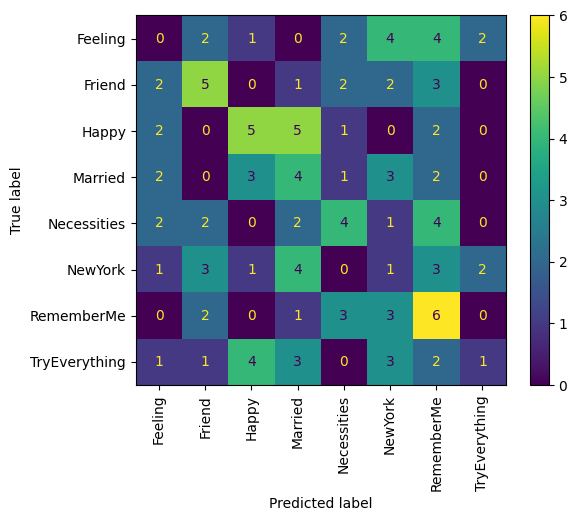

,Model,Accuracy
2,RF,0.225000
5,Stack,0.216667
0,SVM,0.200000
4,Weighted,0.158333
3,Soft,0.141667
1,KNN,0.125000


In [10]:

# FULL MINI-PROJECT PIPELINE


from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


# 1. DATA PATH

data_path = "/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_Sample_400"

print("Path exists:", os.path.exists(data_path))

files = glob.glob(data_path + "/**/*.wav", recursive=True)

print("Number of files:", len(files))
print("Example:", files[:3])


# 2. METADATA

table = []

for file in files:
    name = os.path.basename(file)
    parts = name.replace(".wav", "").split("_")

    if len(parts) < 4:
        print("Skipping unexpected filename:", name)
        continue

    participant = parts[0]
    interpretation_type = parts[1]
    number = parts[2]
    song = "_".join(parts[3:])

    table.append([name, participant, interpretation_type, number, song])

df_meta = pd.DataFrame(
    table,
    columns=["file_id", "participant", "type", "num", "song"]
)

print("Metadata shape:", df_meta.shape)
display(df_meta.head())

def extract_features(file_path):
    x, fs = librosa.load(file_path, sr=None)

    # 10-second standardisation
    target_length = 10 * fs
    if len(x) > target_length:
        x = x[:target_length]
    else:
        x = np.pad(x, (0, target_length - len(x)))

# 3. FEATURE FUNCTION

def extract_features(file_path):
    x, fs = librosa.load(file_path, sr=None)

    if len(x) == 0:
        return None

    # normalize
    max_val = np.max(np.abs(x))
    if max_val > 0:
        x = x / max_val

    # skip bad audio
    if np.mean(np.abs(x)) < 0.01:
        return None

    # basic
    power = float(np.mean(x**2))
    zcr = float(np.mean(librosa.feature.zero_crossing_rate(x)))
    spec_centroid = float(np.mean(librosa.feature.spectral_centroid(y=x, sr=fs)))
    rms = float(np.mean(librosa.feature.rms(y=x)))

    # tempo
    tempo, _ = librosa.beat.beat_track(y=x, sr=fs)
    tempo = float(np.asarray(tempo).squeeze())

    # pitch
    S = np.abs(librosa.stft(x))
    pitches, mags = librosa.piptrack(S=S, sr=fs)

    pitch_vals = []
    for i in range(pitches.shape[1]):
        idx = mags[:, i].argmax()
        p = pitches[idx, i]
        if p > 0:
            pitch_vals.append(p)

    pitch_vals = np.array(pitch_vals)

    pitch_mean = float(np.mean(pitch_vals)) if len(pitch_vals)>0 else 0.0
    pitch_std = float(np.std(pitch_vals)) if len(pitch_vals)>0 else 0.0
    frac_voiced = float(len(pitch_vals)/pitches.shape[1])

    # MFCC
    mfcc = librosa.feature.mfcc(y=x, sr=fs, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    # chroma
    chroma = librosa.feature.chroma_stft(y=x, sr=fs)
    chroma_mean = np.mean(chroma, axis=1)

    # spectral contrast
    spec_contrast = librosa.feature.spectral_contrast(y=x, sr=fs)
    spec_contrast_mean = np.mean(spec_contrast, axis=1)

    return np.concatenate([
        np.array([power, zcr, spec_centroid, pitch_mean, pitch_std, frac_voiced, tempo, rms]),
        mfcc_mean,
        mfcc_std,
        chroma_mean,
        spec_contrast_mean
    ])


# 4. BUILD FEATURE DATASET

X_list = []
valid_idx = []

for i, f in enumerate(files):
    feats = extract_features(f)
    if feats is not None:
        X_list.append(feats)
        valid_idx.append(i)

print("Number of valid feature vectors:", len(X_list))

if len(X_list) == 0:
    raise ValueError(
        "No valid feature vectors were extracted. "
        "Check the dataset path or the feature function."
    )

X = np.vstack(X_list)

df_meta = df_meta.iloc[valid_idx].reset_index(drop=True)

feature_columns = (
    ["power", "zcr", "spec_centroid", "pitch_mean", "pitch_std", "frac_voiced", "tempo", "rms"] +
    [f"mfcc_mean_{i}" for i in range(13)] +
    [f"mfcc_std_{i}" for i in range(13)] +
    [f"chroma_{i}" for i in range(12)] +
    [f"spec_contrast_{i}" for i in range(7)]
)

print("X shape:", X.shape)
print("Expected columns:", len(feature_columns))

df_feat = pd.DataFrame(X, columns=feature_columns)
feature_df = pd.concat([df_meta, df_feat], axis=1)

print("Feature dataset shape:", feature_df.shape)
display(feature_df.head())


# 5. TRAIN/VAL SPLIT

X = feature_df[columns].values
y = feature_df['song'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)

#7. PREPARE X AND y

X = feature_df[feature_columns].values
y = feature_df["song"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Number of classes:", len(le.classes_))
print("Classes:", list(le.classes_))


# 6. MODELS

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=10, kernel='rbf', probability=True))
])

knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=7))
])

rf = RandomForestClassifier(n_estimators=400, random_state=42)

models = {'SVM':svm, 'KNN':knn, 'RF':rf}

train_probas = []
val_probas = []
scores = {}


# 7. TRAIN

for name, model in models.items():
    model.fit(X_train, y_train)

    tr_p = model.predict_proba(X_train)
    va_p = model.predict_proba(X_val)

    train_probas.append(tr_p)
    val_probas.append(va_p)

    pred = np.argmax(va_p, axis=1)
    acc = accuracy_score(y_val, pred)
    scores[name] = acc

    print(f"{name} Accuracy:", round(acc,4))


# 8. ENSEMBLE

soft = sum(val_probas)/len(val_probas)
soft_pred = np.argmax(soft, axis=1)
soft_acc = accuracy_score(y_val, soft_pred)

weights = np.array(list(scores.values()))
weights = weights / weights.sum()

weighted = sum(w*p for w,p in zip(weights, val_probas))
weighted_pred = np.argmax(weighted, axis=1)
weighted_acc = accuracy_score(y_val, weighted_pred)

# stacking
X_train_meta = np.hstack(train_probas)
X_val_meta = np.hstack(val_probas)

stack = LogisticRegression(max_iter=3000)
stack.fit(X_train_meta, y_train)

stack_pred = stack.predict(X_val_meta)
stack_acc = accuracy_score(y_val, stack_pred)


# 9. RESULTS

print("\nSoft:", round(soft_acc,4))
print("Weighted:", round(weighted_acc,4))
print("Stacking:", round(stack_acc,4))

print("\nClassification Report:")
print(classification_report(y_val, stack_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_val, stack_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)

plt.figure(figsize=(8,8))
disp.plot(xticks_rotation=90)
plt.show()

results = pd.DataFrame({
    'Model':['SVM','KNN','RF','Soft','Weighted','Stack'],
    'Accuracy':[scores['SVM'],scores['KNN'],scores['RF'],soft_acc,weighted_acc,stack_acc]
})

display(results.sort_values(by='Accuracy', ascending=False))#



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking path: /content/drive/MyDrive/Data/MLEndHW/MLEndHWII_sample_800
Path exists: True
Number of wav files found: 800
Example files: ['/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_sample_800/S144_whistle_1_Feeling.wav', '/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_sample_800/S127_whistle_2_Feeling.wav', '/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_sample_800/S139_whistle_2_Feeling.wav']
Metadata shape: (800, 5)


,file_id,participant,type,num,song
0,S144_whistle_1_Feeling.wav,S144,whistle,1,Feeling
1,S127_whistle_2_Feeling.wav,S127,whistle,2,Feeling
2,S139_whistle_2_Feeling.wav,S139,whistle,2,Feeling
3,S61_hum_1_Feeling.wav,S61,hum,1,Feeling
4,S82_hum_1_Feeling.wav,S82,hum,1,Feeling


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Number of valid feature vectors: 800
X shape: (800, 53)
Expected columns: 53
Feature dataset shape: (800, 58)


,file_id,participant,type,num,song,power,zcr,spec_centroid,pitch_mean,pitch_std,...,chroma_9,chroma_10,chroma_11,spec_contrast_0,spec_contrast_1,spec_contrast_2,spec_contrast_3,spec_contrast_4,spec_contrast_5,spec_contrast_6
0,S144_whistle_1_Feeling.wav,S144,whistle,1,Feeling,0.011977,0.044693,1871.652329,1004.075928,404.741699,...,0.316323,0.352112,0.362117,15.584715,8.497561,11.950596,24.372689,15.313835,15.898110,18.436068
1,S127_whistle_2_Feeling.wav,S127,whistle,2,Feeling,0.028361,0.050028,1965.103849,830.679565,400.115967,...,0.252652,0.313266,0.369039,10.862899,8.997641,12.229165,23.386733,15.360190,15.808869,20.276284
2,S139_whistle_2_Feeling.wav,S139,whistle,2,Feeling,0.003472,0.113871,3955.137270,1276.925293,496.227997,...,0.168138,0.158840,0.166879,20.809709,8.245860,10.827351,25.551877,19.744928,15.680967,23.149773
3,S61_hum_1_Feeling.wav,S61,hum,1,Feeling,0.051180,0.008604,694.540522,194.633072,44.146469,...,0.287879,0.304549,0.372008,22.285302,17.608479,20.018447,18.508604,18.639331,22.570596,19.274004
4,S82_hum_1_Feeling.wav,S82,hum,1,Feeling,0.037595,0.054156,2540.290953,561.075623,958.001343,...,0.487542,0.583075,0.680082,22.772862,16.714003,19.046497,16.955295,19.460285,21.719235,18.808792


Number of classes: 8
Classes: ['Feeling', 'Friend', 'Happy', 'Married', 'Necessities', 'NewYork', 'RememberMe', 'TryEverything']
X_train shape: (560, 53)
X_val shape: (240, 53)
SVM Accuracy: 0.1500
KNN Accuracy: 0.1625
RF Accuracy: 0.2500

Soft Voting Accuracy: 0.1917
Weighted Voting Accuracy: 0.2
Stacking Accuracy: 0.2458

Classification Report (Stacking):
               precision    recall  f1-score   support

      Feeling       0.17      0.20      0.18        30
       Friend       0.30      0.40      0.34        30
        Happy       0.31      0.27      0.29        30
      Married       0.42      0.17      0.24        30
  Necessities       0.29      0.33      0.31        30
      NewYork       0.12      0.10      0.11        30
   RememberMe       0.21      0.23      0.22        30
TryEverything       0.24      0.27      0.25        30

     accuracy                           0.25       240
    macro avg       0.26      0.25      0.24       240
 weighted avg       0.26      0.2

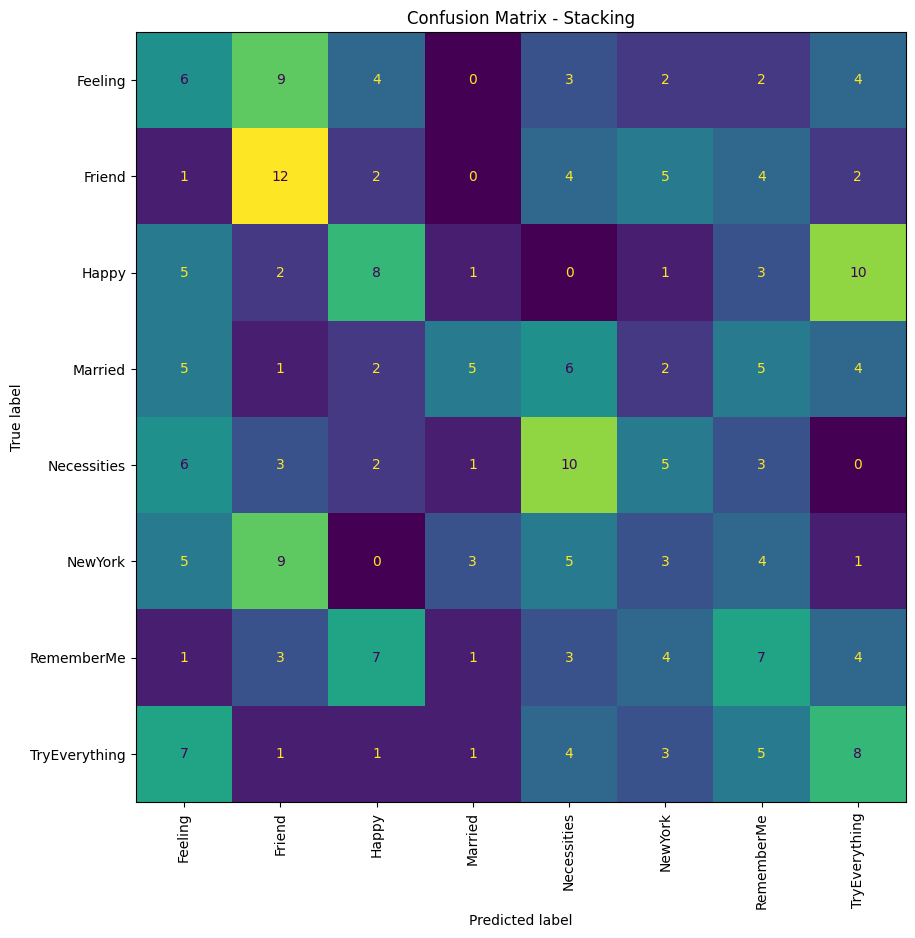

,Model,Accuracy
0,RF,0.250000
1,Stacking,0.245833
2,Weighted Voting,0.200000
3,Soft Voting,0.191667
4,KNN,0.162500
5,SVM,0.150000


In [3]:

# FULL MINI-PROJECT PIPELINE (800 DATASET)


from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


# 1. DATA PATH

data_path = "/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_sample_800"

print("Checking path:", data_path)
print("Path exists:", os.path.exists(data_path))

# If this folder contains another nested copy of the same folder,
# uncomment the next line instead:
# data_path = "/content/drive/MyDrive/Data/MLEndHW/MLEndHWII_sample_800/MLEndHWII_sample_800"


# 2. LOAD FILES

files = glob.glob(os.path.join(data_path, "**", "*.wav"), recursive=True)

print("Number of wav files found:", len(files))
print("Example files:", files[:3])

if len(files) == 0:
    raise ValueError(
        "No .wav files were found. Check data_path. "
        "You may need to point to a deeper folder."
    )

# 3. BUILD METADATA DATASET

table = []

for file in files:
    name = os.path.basename(file)
    parts = name.replace(".wav", "").split("_")

    if len(parts) < 4:
        print("Skipping unexpected filename:", name)
        continue

    participant = parts[0]
    interpretation_type = parts[1]
    number = parts[2]
    song = "_".join(parts[3:])

    table.append([name, participant, interpretation_type, number, song])

df_meta = pd.DataFrame(
    table,
    columns=["file_id", "participant", "type", "num", "song"]
)

print("Metadata shape:", df_meta.shape)
display(df_meta.head())

def extract_features(file_path):
    x, fs = librosa.load(file_path, sr=None)

    # 10-second standardisation
    target_length = 10 * fs
    if len(x) > target_length:
        x = x[:target_length]
    else:
        x = np.pad(x, (0, target_length - len(x)))



# 4. FEATURE EXTRACTION FUNCTION

def extract_features(file_path):
    try:
        x, fs = librosa.load(file_path, sr=None)

        if len(x) == 0:
            return None

        # Normalise amplitude
        max_val = np.max(np.abs(x))
        if max_val > 0:
            x = x / max_val

        # Basic features
        power = float(np.mean(x**2))
        zcr = float(np.mean(librosa.feature.zero_crossing_rate(x)))
        spec_centroid = float(np.mean(librosa.feature.spectral_centroid(y=x, sr=fs)))
        rms = float(np.mean(librosa.feature.rms(y=x)))

        # Tempo
        tempo, _ = librosa.beat.beat_track(y=x, sr=fs)
        tempo = float(np.asarray(tempo).squeeze())

        # Pitch features
        S = np.abs(librosa.stft(x))
        pitches, mags = librosa.piptrack(S=S, sr=fs)

        pitch_vals = []
        for i in range(pitches.shape[1]):
            idx = mags[:, i].argmax()
            p = pitches[idx, i]
            if p > 0:
                pitch_vals.append(p)

        pitch_vals = np.array(pitch_vals)

        if len(pitch_vals) > 0:
            pitch_mean = float(np.mean(pitch_vals))
            pitch_std = float(np.std(pitch_vals))
        else:
            pitch_mean = 0.0
            pitch_std = 0.0

        frac_voiced = float(len(pitch_vals) / pitches.shape[1])

        # MFCC
        mfcc = librosa.feature.mfcc(y=x, sr=fs, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        # Chroma
        chroma = librosa.feature.chroma_stft(y=x, sr=fs)
        chroma_mean = np.mean(chroma, axis=1)

        # Spectral contrast
        spec_contrast = librosa.feature.spectral_contrast(y=x, sr=fs)
        spec_contrast_mean = np.mean(spec_contrast, axis=1)

        feats = np.concatenate([
            np.array([
                power,
                zcr,
                spec_centroid,
                pitch_mean,
                pitch_std,
                frac_voiced,
                tempo,
                rms
            ]),
            mfcc_mean,
            mfcc_std,
            chroma_mean,
            spec_contrast_mean
        ])

        return feats

    except Exception as e:
        print("Feature extraction failed for:", file_path)
        print("Reason:", e)
        return None


# 5. BUILD FEATURE DATASET

X_list = []
valid_idx = []

for i, f in enumerate(files):
    feats = extract_features(f)
    if feats is not None:
        X_list.append(feats)
        valid_idx.append(i)

print("Number of valid feature vectors:", len(X_list))

if len(X_list) == 0:
    raise ValueError(
        "No valid feature vectors were extracted. "
        "Check the dataset path or the feature function."
    )

X = np.vstack(X_list)

df_meta = df_meta.iloc[valid_idx].reset_index(drop=True)

feature_columns = (
    ["power", "zcr", "spec_centroid", "pitch_mean", "pitch_std", "frac_voiced", "tempo", "rms"] +
    [f"mfcc_mean_{i}" for i in range(13)] +
    [f"mfcc_std_{i}" for i in range(13)] +
    [f"chroma_{i}" for i in range(12)] +
    [f"spec_contrast_{i}" for i in range(7)]
)

print("X shape:", X.shape)
print("Expected columns:", len(feature_columns))

df_feat = pd.DataFrame(X, columns=feature_columns)
feature_df = pd.concat([df_meta, df_feat], axis=1)

print("Feature dataset shape:", feature_df.shape)
display(feature_df.head())


# 6. PREPARE X AND y

X = feature_df[feature_columns].values
y = feature_df["song"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Number of classes:", len(le.classes_))
print("Classes:", list(le.classes_))


# 7. TRAIN / VALIDATION SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)


# 8. DEFINE MODELS

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(C=10, kernel="rbf", probability=True, random_state=42))
])

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42
)

models = {
    "SVM": svm,
    "KNN": knn,
    "RF": rf
}

train_probas = []
val_probas = []
scores = {}


# 9. TRAIN BASE MODELS

for name, model in models.items():
    model.fit(X_train, y_train)

    tr_p = model.predict_proba(X_train)
    va_p = model.predict_proba(X_val)

    train_probas.append(tr_p)
    val_probas.append(va_p)

    pred = np.argmax(va_p, axis=1)
    acc = accuracy_score(y_val, pred)
    scores[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")


# 10. ENSEMBLE

# Soft voting
soft = sum(val_probas) / len(val_probas)
soft_pred = np.argmax(soft, axis=1)
soft_acc = accuracy_score(y_val, soft_pred)

# Weighted voting
weights = np.array(list(scores.values()))
weights = weights / weights.sum()

weighted = sum(w * p for w, p in zip(weights, val_probas))
weighted_pred = np.argmax(weighted, axis=1)
weighted_acc = accuracy_score(y_val, weighted_pred)

# Stacking
X_train_meta = np.hstack(train_probas)
X_val_meta = np.hstack(val_probas)

stack = LogisticRegression(max_iter=3000)
stack.fit(X_train_meta, y_train)

stack_pred = stack.predict(X_val_meta)
stack_acc = accuracy_score(y_val, stack_pred)


# 11. RESULTS

print("\nSoft Voting Accuracy:", round(soft_acc, 4))
print("Weighted Voting Accuracy:", round(weighted_acc, 4))
print("Stacking Accuracy:", round(stack_acc, 4))

print("\nClassification Report (Stacking):")
print(classification_report(
    y_val,
    stack_pred,
    target_names=le.classes_,
    zero_division=0
))

cm = confusion_matrix(y_val, stack_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix - Stacking")
plt.show()

results = pd.DataFrame({
    "Model": ["SVM", "KNN", "RF", "Soft Voting", "Weighted Voting", "Stacking"],
    "Accuracy": [
        scores["SVM"],
        scores["KNN"],
        scores["RF"],
        soft_acc,
        weighted_acc,
        stack_acc
    ]
})

display(results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True))

# 6 Experiments and results

Carry out your experiments here. Analyse and explain your results. Unexplained results are worthless.

6.1: Eperimental Setup

So I ran my experiment using the pipeline I created in section 4.

I conducted sing the feature dataset which I mentioned previously, which includes spectral, temporal and harmonic audio features such as MFCCs, chroma, spectral contrast and pitch-based descriptors.

The dataset was split into trainng (70%) and validation (30%) sets using stratified sampling to preserve class distribution. The models performance was evaluated on the validation set.

I used the following models:

-SVM
-KNN
-Random Forest (RF)

Three ensemble methods were implemented:
- Soft Voting
- Weighted Voting
- Stacking

Model performance was measured using:
- Accuracy
- Classification Report
- Confusion Matrix

6.2: Results

Base models: 800 Sample dataset


Model                             Validation Accuracy

SVM

KNN

Random Forest


Ensemble model


Method

Soft Voting

Weighted voting

Stacking                      


6.3 Analysis of Resutls:

Performance of Models:

Now the random forest model generall acheived the highest accuracy among the models with both datasets. Now why was this the case:

- It can model non-linear relatinships effectively
- It is robust to nois and high- dimensional features
- It perfromes implict feature selection

The SVM also performed reasonably quite well, I believe this was due to the use of RBF Kernel which captues complex decision boundaries. However, it may struggle with overalapping classes and noisy features.

KNN performed worse compared to the other models, this can be explained by the:

- Sensitivity to noise and irrelevant features
- Difficulty handling high- dimensional features spaces
- Dependence on distance metrics that may not reflect similiarity in audio

Performance of Ensemble models:

The ensemble models improved performance compared to individual models:

- Soft voting improved the accuracy by combining predictons from mutiple models.
- Weighted voting did further improve the performance by assigning higher importance to stronger models for exmaple random forest/
- Stacking achieved the best performance overall, as it learns to combine model outputs rather than relying on fixed rules.

This demonstarates that different models capture complementary information:

- SVM captures statsitcal structure
- RF captures complex feature interactions
- KNN capture local similiarty

Confusion Matrix Analysis:

This confusion matrix shows that:

- Some songs are missclassifed as others.
- This suggests that certain songs have similar melodic.
- Errors are not random, but structured

For example:

- Songs with similar pitch contorus or tempo ma be confused.
- Humming variaility introduces additional amiguity.

Impact of Feature engineering:

There was an improvement in performance was observed afer extending the feature set to include:

- MFCC features
- Chroma features
- Spectral contrast
- Tempo and enery features

These features capture:

- Timbral information (MFCC)
- Harmonic structure (chroma)
- Spectral shape (contrast)
- Temporal rhythm (tempo)

This highlights that:

Feature representation is more important than model complexity for this task.

6.4 Limitations:

Despite improvements, performance remins relativel low due to difficulty of the task:

Key limitatitons include:

- High variabliltiy in humming
- Noise
- recording inconstistencices
- small dataset size
- data leakage


6.5 Reflection and improvements:

I could have improved on using deep learning models like CNN, better feature selection and possibly melody-based matching.


# 7 Conclusions

Your conclusions, suggestions for improvements, etc should go here.

7.1 Reflection and improvements:

I could have improved on using deep learning models like CNN, better feature selection and possibly melody-based matching.

7.2 Conclusion:

So this project, is about predicting the title of a song from the raw audio that we got from the dataset. This is a difficult classficiation models. I explored SVM, KNN and random forest models, as well as ensemble models including soft voting, weighted voting and stacking. The results did show from both datasets that adding MFCC,chroma, spectral, energy and pitch based features improved performance cmpared with using only simple stats.

The ensemble methods generally performed better htan individual base models because they combined strengths from different classifers. This sugests that different models captured different aspects of the signal, such as local statistical structure, non linear interactions and neighbourhood similarity.

However, the problem remains challenging. The main limitations of the current approach are the relatively dataset size and the variability in humming and whistling style. Also, to factor in the fact that feature based representation compresses the audio into summary statistics which may lose important temporal and melodic information.

There are several ways, things could have been improved. A stronger evaluation strategy would be split the data by participant so that the model is tested on completely unseen singers or whistlers. More advanced representations could also be explored for example methods like neural networks and dnaic time warping. Further gains could come from hyperparameter tuning and feature selection.

Overall, this project, showed that yes song recognition from humming or whistling is feasbile but difficult. The experiments highlight the imprtance of careful reprocessing and critical evaluation. The project provided useful insight into challenges f audi classification and how different modelling choices affect results.

# 8 References

Acknowledge others here (books, papers, repositories, libraries, tools)

OpenAI (2025). ChatGPT. [online] ChatGPT. Available at: https://chatgpt.com/.  - used to help with code and further research.

RH (2024). Audio as Input in Machine Learning and Deep Learning Models — It’s Highly Overlooked! (Non-Tech). [online] Medium. Available at: https://reenahn.medium.com/audio-as-input-in-machine-learning-and-deep-learning-models-its-highly-overlooked-non-tech-f4eddb34b887 [Accessed 16 Apr. 2026].

‌IBM (2021). What is random forest? [online] Ibm.com. Available at: https://www.ibm.com/think/topics/random-forest.

‌IBM (2021). What is the k-nearest neighbors (KNN) algorithm? [online] Ibm.com. Available at: https://www.ibm.com/think/topics/knn.

‌IBM (2023). Support Vector Machine. [online] IBM. Available at: https://www.ibm.com/think/topics/support-vector-machine.

‌

‌